# Import Libraries

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split


# Path to dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


# Display Sample Images from Dataset

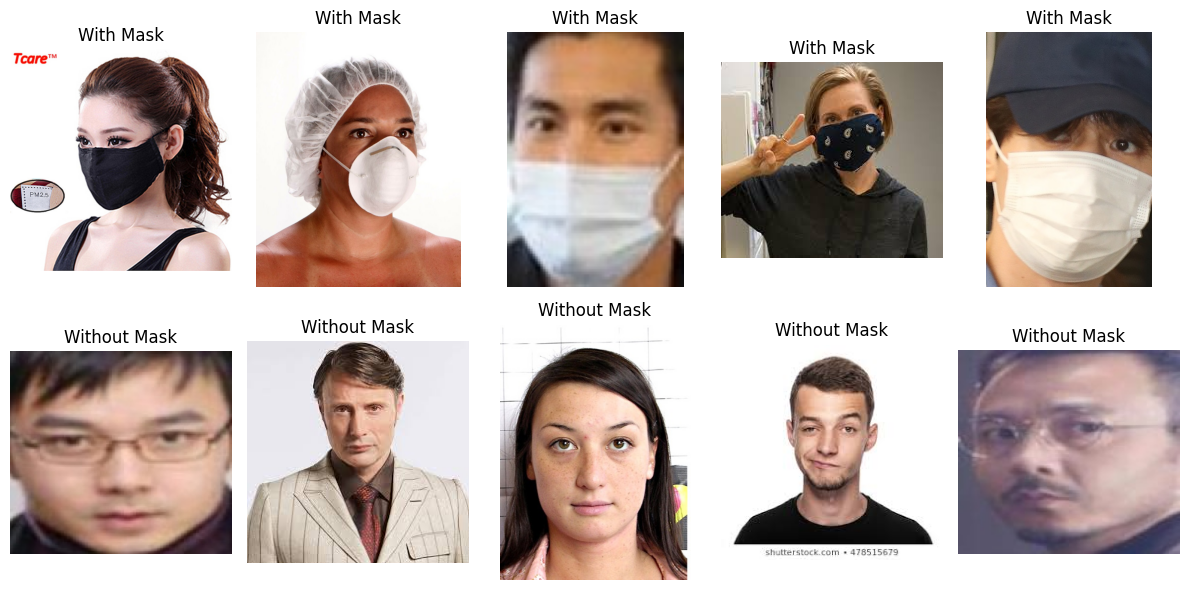

In [8]:
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Set dataset path
dataset_path = os.path.join(path, "data")   # using kagglehub 'path'

with_mask_path = os.path.join(dataset_path, "with_mask")
without_mask_path = os.path.join(dataset_path, "without_mask")

# Get file names
with_mask_images = os.listdir(with_mask_path)[:5]       # first 5 images
without_mask_images = os.listdir(without_mask_path)[:5] # first 5 images

plt.figure(figsize=(12, 6))

# Display With Mask
for i, img_name in enumerate(with_mask_images):
    img = imread(os.path.join(with_mask_path, img_name))
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title("With Mask")
    plt.axis("off")

# Display Without Mask
for i, img_name in enumerate(without_mask_images):
    img = imread(os.path.join(without_mask_path, img_name))
    plt.subplot(2, 5, i+6)
    plt.imshow(img)
    plt.title("Without Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Load data with automatic Train/Test split

In [4]:
IMG_SIZE = 150
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,    # 20% for testing
    rotation_range=15,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

test_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


# Build CNN model

In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# Train the CNN

In [6]:
history = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
112/189 ━━━━━━━━━━━━━━━━━━━━ 29s 381ms/step - accuracy: 0.7096 - loss: 0.5431

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 101s 503ms/step - accuracy: 0.7550 - loss: 0.4814 - val_accuracy: 0.8834 - val_loss: 0.3211
Epoch 2/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 55s 293ms/step - accuracy: 0.8772 - loss: 0.2942 - val_accuracy: 0.9225 - val_loss: 0.2214
Epoch 3/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 56s 296ms/step - accuracy: 0.8916 - loss: 0.2598 - val_accuracy: 0.9358 - val_loss: 0.1895
Epoch 4/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 276ms/step - accuracy: 0.9000 - loss: 0.2307 - val_accuracy: 0.9272 - val_loss: 0.2076
Epoch 5/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 275ms/step - accuracy: 0.9241 - loss: 0.2046 - val_accuracy: 0.9391 - val_loss: 0.1735
Epoch 6/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 56s 297ms/step - accuracy: 0.9392 - loss: 0.1685 - val_accuracy: 0.9510 - val_loss: 0.1569
Epoch 7/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 271ms/step - accuracy: 0.9386 - loss: 0.1664 - val_accuracy: 0.9457 - val_loss: 0.1671
Epoch 8/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 51s 271ms/step - accuracy: 0.9408 - loss: 0.1551 - va

# Evaluate

In [7]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)


48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.9555 - loss: 0.1195
Test Accuracy: 0.9629139304161072


# Predict on a single image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


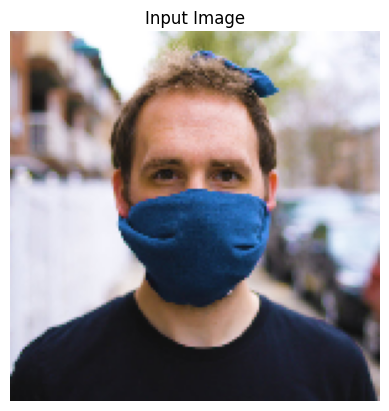

Mask Detected 😷


In [10]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "sample.jpg"   # your image file

# Load and preprocess
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img) / 255.0
img_expanded = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_expanded)[0][0]

# Display image
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

# Print prediction
if prediction < 0.5:
    print("Mask Detected 😷")
else:
    print("No Mask Detected 😐")
